# AIAP Batch 24 Technical Assessment - Exploratory Data Analysis (EDA)
**Candidate Name:** [Suryanto]  
**Date:** [05/06/2026]  

## Objective
The goal of this notebook is to explore the MoveEasy delivery dataset to understand the factors contributing to the drop in customer ratings (from 4.4 to 3.9).

We will analyze delivery records and customer feedback to define what constitutes "trouble" and identify key drivers of poor delivery experiences, enabling the dispatch team to prioritize their attention.

## 0. Preparation and Setup


In [1]:
# Get system Datetime (just to prevent caching and report runs correctly in case of code change)
from datetime import datetime

# Get current system date and time
now = datetime.now()
print("System Datetime (UTC):", now)

System Datetime (UTC): 2026-06-07 15:04:20.504179


In [2]:
# ==========================================
# 0. Preparation and Setup
# ==========================================
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# ==========================================
# 1. Initial Data Inspection & Loading
# ==========================================
db_path = 'data/delivery.db'

# 1.1 Verify file existence
if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found at {db_path}. Please check the file name and location.")

# Check the actual file type
!file data/delivery.db

# 1.2 Single Connection for Inspection AND Full Loading
print(f"Connecting to: {db_path}")
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 1.3 Get and print table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]
print(f"Successfully connected! Tables found: {tables}\n")

# 1.4 Load tables directly into Pandas (Single Connection)
df_records = pd.read_sql_query("SELECT * FROM deliveries", conn)
df_feedback = pd.read_sql_query("SELECT * FROM feedback", conn)
#conn.close()

print(f"Delivery Records shape: {df_records.shape}")
print(f"Customer Feedback shape: {df_feedback.shape}\n")


# 1.5 Loop through tables: Preview first 10 rows AND load full data
for table_name in tables:
    print(f"=== First 10 rows of: '{table_name}' ===")

    # A. Display first 10 rows (Inspection)
    query_preview = f"SELECT * FROM '{table_name}' LIMIT 10"
    df_preview = pd.read_sql_query(query_preview, conn)
    display(df_preview)
    print("\n")

    # B. Load full table into memory (Data Loading)
    if table_name == 'deliveries':
        df_records = pd.read_sql_query(f"SELECT * FROM '{table_name}'", conn)
    elif table_name == 'feedback':
        df_feedback = pd.read_sql_query(f"SELECT * FROM '{table_name}'", conn)


data/delivery.db: SQLite 3.x database, last written using SQLite version 3050004, file counter 6, database pages 10018, cookie 0x4, schema 4, UTF-8, version-valid-for 6
Connecting to: data/delivery.db
Successfully connected! Tables found: ['deliveries', 'feedback']

Delivery Records shape: (150750, 18)
Customer Feedback shape: (54972, 5)

=== First 10 rows of: 'deliveries' ===


,delivery_id,branch,client_id,booking_datetime,pickup_datetime,promised_delivery_datetime,delivery_datetime,distance_km,parcel_weight_kg,parcel_value_sgd,parcel_category,delivery_priority,num_stops_on_route,driver_id,driver_experience_months,vehicle_type,payment_method,recipient_postal_code
0,D2026000000,North,C0000,2026-01-17 16:10:11.419632,2026-01-17 18:14:42.141079,2026-01-18 00:10:11.419632,2026-01-17 23:58:29.106853,5.86,0.585,102.05,standard,Standard,62.0,DRV0130,2.0,van,prepaid,57
1,D2026000001,North,C0007,2025-12-06 15:33:02.496777,2025-12-06 16:11:03.931680,2025-12-06 19:33:02.496777,2025-12-06 18:53:45.937422,3.10,3.292,105.17,standard,Express,NaN,DRV0087,33.0,van,cod,73
2,D2026000002,East,C0000,2026-04-20 16:32:08.934038,2026-04-20 19:54:14.157180,2026-04-21 00:32:08.934038,2026-04-21 00:06:28.451910,8.03,1.426,36.48,standard,Standard,35.0,DRV0040,35.0,van,cod,51
3,D2026000003,East,C0002,2026-05-11 12:15:01.850095,2026-05-11 14:44:34.713623,2026-05-11 20:15:01.850095,2026-05-11 21:29:30.086468,6.06,2.163,71.8,fragile,Standard,90.0,DRV0109,9.0,van,prepaid,49
4,D2026000004,North,C0009,2026-05-20 14:32:47.616722,2026-05-20 15:50:24.743132,2026-05-20 18:32:47.616722,2026-05-20 17:46:23.101404,4.65,0.7,18.05,standard,Express,54.0,DRV0085,24.0,bike,prepaid,73
5,D2026000005,East,C0001,2026-01-12 13:29:40.407577,2026-01-12 15:22:09.840781,2026-01-12 17:29:40.407577,2026-01-12 16:58:11.176275,5.59,3.268,57.17,standard,Express,56.0,DRV0048,14.0,van,prepaid,49
6,D2026000006,Central,C0014,2026-01-12 13:03:33.189437,2026-01-12 13:27:34.824832,2026-01-12 17:03:33.189437,2026-01-12 16:45:35.092919,3.82,NaN,33.03,standard,Express,70.0,DRV0048,6.0,bike,prepaid,04
7,D2026000007,West,C0000,2026-02-05 15:10:52.354268,2026-02-05 15:53:46.636055,2026-02-05 17:10:52.354268,2026-02-05 16:47:03.457854,6.84,2.83,106.98,standard,Premium,39.0,DRV0057,9.0,van,cod,13
8,D2026000008,East,C0000,2026-03-26 16:53:32.745813,2026-03-26 17:27:54.978761,2026-03-26 20:53:32.745813,2026-03-26 20:28:33.172024,2.99,2.334,52.28,standard,Express,52.0,DRV0099,9.0,van,prepaid,47
9,D2026000009,West,C0010,2026-01-04 16:11:43.471632,2026-01-04 18:53:47.771123,2026-01-05 00:11:43.471632,2026-01-04 23:38:51.398949,3.44,1.076,29.37,standard,Standard,24.0,DRV0153,19.0,van,prepaid,23




=== First 10 rows of: 'feedback' ===


,feedback_id,delivery_id,rating,comment,feedback_datetime
0,F01000000,D2026000001,5.0,"On time as always, thanks! Driver very polite,...",2025-12-07 02:17:46.889241
1,F01000001,D2026000003,3.0,Delivery was acceptable.,2026-05-12 11:00:52.289329
2,F01000002,D2026000011,5.0,"Great experience, no complaints.",2026-04-11 08:19:49.177079
3,F01000003,D2026000012,5.0,,2025-12-31 11:57:23.657124
4,F01000004,D2026000013,4.0,,2026-02-24 04:52:01.214870
5,F01000005,D2026000016,5.0,"Driver called ahead, super helpful.",2025-12-23 02:42:53.108333
6,F01000006,D2026000020,5.0,"Delivered ahead of schedule, very impressed.",2025-12-23 03:55:14.365504
7,F01000007,D2026000024,5.0,"Smooth delivery, will use again.",2026-03-31 22:00:39.851346
8,F01000008,D2026000026,5.0,"Smooth delivery, will use again.",2026-04-03 23:23:44.151473
9,F01000009,D2026000030,5.0,"Great experience, no complaints.",2026-05-04 18:05:18.851333


## 1. Initial Data Inspection & Merging and Resolve Duplicate Feedback
Before diving into analysis, we need to understand the structure of our datasets, ensure data types are correct (especially for datetime columns), and merge the feedback with the delivery records. We use a `left join` to ensure we keep all delivery records, even those where the customer did not leave feedback.

In [3]:
# ==========================================
# 1. Data Type Conversion
# ==========================================
# A. Convert datetime columns efficiently (Vectorized)
datetime_cols_records = ['booking_datetime', 'pickup_datetime', 'promised_delivery_datetime', 'delivery_datetime']
datetime_cols_feedback = ['feedback_datetime']

df_records[datetime_cols_records] = df_records[datetime_cols_records].apply(pd.to_datetime, errors='coerce')
df_feedback[datetime_cols_feedback] = df_feedback[datetime_cols_feedback].apply(pd.to_datetime, errors='coerce')

# ==========================================
# 2. Initial State & Raw Ratio Calculation
# ==========================================
print("="*60)
print("DATA QUALITY & FEEDBACK RATIO ANALYSIS")
print("="*60)

# CAPTURE RAW COUNTS BEFORE ANY CLEANING
total_deliveries = len(df_records)
raw_feedback_count = len(df_feedback)
raw_ratio = (raw_feedback_count / total_deliveries) * 100

print(f"\n[Original Raw Data]")
print(f"Total Deliveries:       {total_deliveries:,}")
print(f"Raw Feedback Entries:   {raw_feedback_count:,}")
print(f"Raw Feedback Ratio:     {raw_feedback_count:,} / {total_deliveries:,} = {raw_ratio:.2f}%\n")

# ==========================================
# 3. Investigate Duplicates
# ==========================================
print("--- Investigating Duplicates ---")
duplicate_feedback = df_feedback[df_feedback.duplicated(subset=['delivery_id'], keep=False)]
num_duplicate_ids = duplicate_feedback['delivery_id'].nunique()

if num_duplicate_ids > 0:
    print(f"⚠️ Found {num_duplicate_ids} unique delivery_ids with multiple feedback entries.")
    print(f"   Total duplicate rows involved: {len(duplicate_feedback)}")

    # Show a concrete example to understand the nature of the duplicates
    example_id = duplicate_feedback['delivery_id'].iloc[0]
    print(f"\n🔍 Example of duplicate feedback for delivery_id '{example_id}':")
    display(duplicate_feedback[duplicate_feedback['delivery_id'] == example_id].sort_values('feedback_datetime'))
else:
    print("✅ No duplicate delivery_ids found in feedback table.")

# ==========================================
# 4. RESOLVE: Deduplicate the feedback table
# ==========================================
print("\n--- Resolving Duplicates ---")
# Sort by delivery_id and feedback_datetime to ensure we keep the MOST RECENT feedback
df_feedback = df_feedback.sort_values(by=['delivery_id', 'feedback_datetime'])

# Drop duplicates, keeping only the last (most recent) entry per delivery_id
df_feedback = df_feedback.drop_duplicates(subset=['delivery_id'], keep='last').reset_index(drop=True)

# ==========================================
# 5. Calculate Cleaned Counts & Accurate Ratio (AFTER Dropping)
# ==========================================
cleaned_feedback_count = len(df_feedback)
duplicates_removed = raw_feedback_count - cleaned_feedback_count
cleaned_ratio = (cleaned_feedback_count / total_deliveries) * 100

print(f"Cleaned Feedback shape: {df_feedback.shape} (Removed {duplicates_removed} redundant rows)")

print(f"\n[Cleaned Data & Accurate Ratio]")
print(f"Cleaned Feedback Entries:  {raw_feedback_count:,} - {duplicates_removed} = {cleaned_feedback_count:,}")
print(f"Accurate Cleaned Ratio:    {cleaned_feedback_count:,} / {total_deliveries:,} = {cleaned_ratio:.2f}%")

# ==========================================
# 6. Merge and Verify
# ==========================================
print("\n" + "="*60)
print("MERGING DATASETS")
print("="*60)

df_merged = pd.merge(df_records, df_feedback, on='delivery_id', how='left')

print(f"\nDelivery Records shape: {df_records.shape}")
print(f"Merged dataset shape:   {df_merged.shape}")

# Safety check: Ensure the left join no longer inflates the row count
if df_merged.shape[0] == df_records.shape[0]:
    print("✅ SUCCESS: Merged dataset row count perfectly matches original delivery records (No row inflation).")
else:
    print(f"❌ WARNING: Row count mismatch! Merged has {df_merged.shape[0] - df_records.shape[0]} extra rows.")

# Visual verification of the merge
print("\n--- Merged Data Preview ---")
display(df_merged.head())

# Updated Missing Values Summary (Sorted for readability)
print("\n--- Updated Missing Values Summary ---")
display(df_merged.isnull().sum()[df_merged.isnull().sum() > 0].sort_values(ascending=False))


# ==========================================
# 7.  Data Cleaning: Fix Inconsistent Categories
# ==========================================
cat_cols_to_clean = ['branch', 'parcel_category', 'delivery_priority', 'vehicle_type', 'payment_method']

for col in cat_cols_to_clean:
    # 1. Convert to string, strip whitespace, and apply Title Case
    # (This merges "east", "EAST", and "East" into "East")
    df_merged[col] = df_merged[col].astype(str).str.strip().str.title()

    # 2. Fix specific typos and inconsistencies observed in your charts
    if col == 'branch':
        df_merged[col] = df_merged[col].replace('Cnetral', 'Central')
        df_merged[col] = df_merged[col].replace('Noth', 'North')

    if col == 'parcel_category':
        df_merged[col] = df_merged[col].replace('Over-Sized', 'Oversized')
        df_merged[col] = df_merged[col].replace('Refrig.', 'Refrigerated')


print("Categorical data cleaned successfully.")

DATA QUALITY & FEEDBACK RATIO ANALYSIS

[Original Raw Data]
Total Deliveries:       150,750
Raw Feedback Entries:   54,972
Raw Feedback Ratio:     54,972 / 150,750 = 36.47%

--- Investigating Duplicates ---
⚠️ Found 273 unique delivery_ids with multiple feedback entries.
   Total duplicate rows involved: 546

🔍 Example of duplicate feedback for delivery_id 'D2026000494':


,feedback_id,delivery_id,rating,comment,feedback_datetime
173,F01000173,D2026000494,5.0,Polite and professional driver.,2026-05-25 21:50:23.155392
54931,F01000173,D2026000494,5.0,Polite and professional driver.,2026-05-25 21:50:23.155392



--- Resolving Duplicates ---
Cleaned Feedback shape: (54699, 5) (Removed 273 redundant rows)

[Cleaned Data & Accurate Ratio]
Cleaned Feedback Entries:  54,972 - 273 = 54,699
Accurate Cleaned Ratio:    54,699 / 150,750 = 36.28%

MERGING DATASETS

Delivery Records shape: (150750, 18)
Merged dataset shape:   (150750, 22)
✅ SUCCESS: Merged dataset row count perfectly matches original delivery records (No row inflation).

--- Merged Data Preview ---


,delivery_id,branch,client_id,booking_datetime,pickup_datetime,promised_delivery_datetime,delivery_datetime,distance_km,parcel_weight_kg,parcel_value_sgd,...,num_stops_on_route,driver_id,driver_experience_months,vehicle_type,payment_method,recipient_postal_code,feedback_id,rating,comment,feedback_datetime
0,D2026000000,North,C0000,2026-01-17 16:10:11.419632,2026-01-17 18:14:42.141079,2026-01-18 00:10:11.419632,2026-01-17 23:58:29.106853,5.86,0.585,102.05,...,62.0,DRV0130,2.0,van,prepaid,57,NaN,NaN,NaN,NaT
1,D2026000001,North,C0007,2025-12-06 15:33:02.496777,2025-12-06 16:11:03.931680,2025-12-06 19:33:02.496777,2025-12-06 18:53:45.937422,3.10,3.292,105.17,...,NaN,DRV0087,33.0,van,cod,73,F01000000,5.0,"On time as always, thanks! Driver very polite,...",2025-12-07 02:17:46.889241
2,D2026000002,East,C0000,2026-04-20 16:32:08.934038,2026-04-20 19:54:14.157180,2026-04-21 00:32:08.934038,2026-04-21 00:06:28.451910,8.03,1.426,36.48,...,35.0,DRV0040,35.0,van,cod,51,NaN,NaN,NaN,NaT
3,D2026000003,East,C0002,2026-05-11 12:15:01.850095,2026-05-11 14:44:34.713623,2026-05-11 20:15:01.850095,2026-05-11 21:29:30.086468,6.06,2.163,71.8,...,90.0,DRV0109,9.0,van,prepaid,49,F01000001,3.0,Delivery was acceptable.,2026-05-12 11:00:52.289329
4,D2026000004,North,C0009,2026-05-20 14:32:47.616722,2026-05-20 15:50:24.743132,2026-05-20 18:32:47.616722,2026-05-20 17:46:23.101404,4.65,0.7,18.05,...,54.0,DRV0085,24.0,bike,prepaid,73,NaN,NaN,NaN,NaT



--- Updated Missing Values Summary ---


rating                      97998
comment                     97948
feedback_datetime           95756
feedback_id                 95756
num_stops_on_route           6135
vehicle_type                 6116
payment_method               6035
parcel_value_sgd             5998
recipient_postal_code        5939
parcel_weight_kg             5907
driver_experience_months     5896
dtype: int64

Categorical data cleaned successfully.


### 🔍 Critical Data Quality Observations


1. **✅ Feedback Ratio Context (including duplicate)**  
   - **Observation:** Only ~36.3% of deliveries receive feedback.  
   - **Implication:** Our "Trouble" definition safely defaults missing feedback to `0` (No Trouble).

   
   
2. **⚠️ Operational Data Missingness (~4% of Dataset)**  
   - **Observation:** Core operational features (`parcel_weight_kg`, `vehicle_type`, `num_stops_on_route`, etc.) have ~5,900–6,100 missing values.  
   - **Implication:** This is not expected "missing feedback"; this is a data capture failure in the operational system. For future enhancement
```





## 2. Defining the Target Variable: "Trouble"
The Head of Operations wants to know "how likely it is to run into trouble". We must operationalize this vague request into a binary target variable.
Based on the business context, a delivery is in "trouble" if:
1. **It is Late:** The actual `delivery_datetime` is after the `promised_delivery_datetime`.
2. **It has a Low Rating:** The customer gave a rating of 2 or below (out of 5).

We will create a new column `is_trouble` where `1` = Trouble, `0` = No Trouble.

Missing feedback is treated as 'No Trouble' (0) for the purpose of this model, as the business goal is to flag known high-risk deliveries. This is expected (not all deliveries get feedback. Alternatively, we can drop rows without feedback if we only want to model explicit feedback, but keeping them with a default '0' is safer for operational coverage.

In [4]:
# ==========================================
# 2. Defining the Target Variable: "Trouble"
# ==========================================

# Calculate delivery delay in minutes
df_merged['delay_minutes'] = (df_merged['delivery_datetime'] - df_merged['promised_delivery_datetime']).dt.total_seconds() / 60

# Define "Trouble" conditions
df_merged['is_low_rating'] = df_merged['rating'].apply(lambda x: 1 if pd.notnull(x) and x <= 2 else 0)
df_merged['is_late'] = df_merged['delay_minutes'].apply(lambda x: 1 if x > 0 else 0)

# A delivery is in "trouble" if it is Late OR has a Low rating
df_merged['is_trouble'] = ((df_merged['is_late'] == 1) | (df_merged['is_low_rating'] == 1)).astype(int)

# ==========================================
# Calculate Metrics & Overlap Ratio
# ==========================================
total_deliveries = len(df_merged)
total_trouble = df_merged['is_trouble'].sum()
late_deliveries = df_merged['is_late'].sum()

# Calculate Overlap Ratio: What % of 'Trouble' cases are strictly due to being late?
overlap_ratio = (late_deliveries / total_trouble) * 100 if total_trouble > 0 else 0

# Print a clean summary
print("="*60)
print("TARGET VARIABLE DEFINITION SUMMARY")
print("="*60)
print(f"Total Deliveries:              {total_deliveries:,}")
print(f"Deliveries in 'Trouble':       {total_trouble:,} ({(total_trouble/total_deliveries)*100:.2f}%)")
print(f"Late Deliveries:               {late_deliveries:,}")
print(f"Overlap Ratio (Late/Trouble):  {overlap_ratio:.2f}%")
print("="*60)
print("💡 Interpretation: An overlap ratio of ~98% proves that nearly all")
print("   trouble cases are driven by lateness alone, making 'delay_minutes'")
print("   the most critical feature for our future ML model.")

TARGET VARIABLE DEFINITION SUMMARY
Total Deliveries:              150,750
Deliveries in 'Trouble':       16,773 (11.13%)
Late Deliveries:               16,533
Overlap Ratio (Late/Trouble):  98.57%
💡 Interpretation: An overlap ratio of ~98% proves that nearly all
   trouble cases are driven by lateness alone, making 'delay_minutes'
   the most critical feature for our future ML model.


## 3. Univariate Analysis
We analyze the distribution of key numerical and categorical features to understand the baseline characteristics of MoveEasy's operations. This helps us identify outliers and understand the typical profile of a delivery.

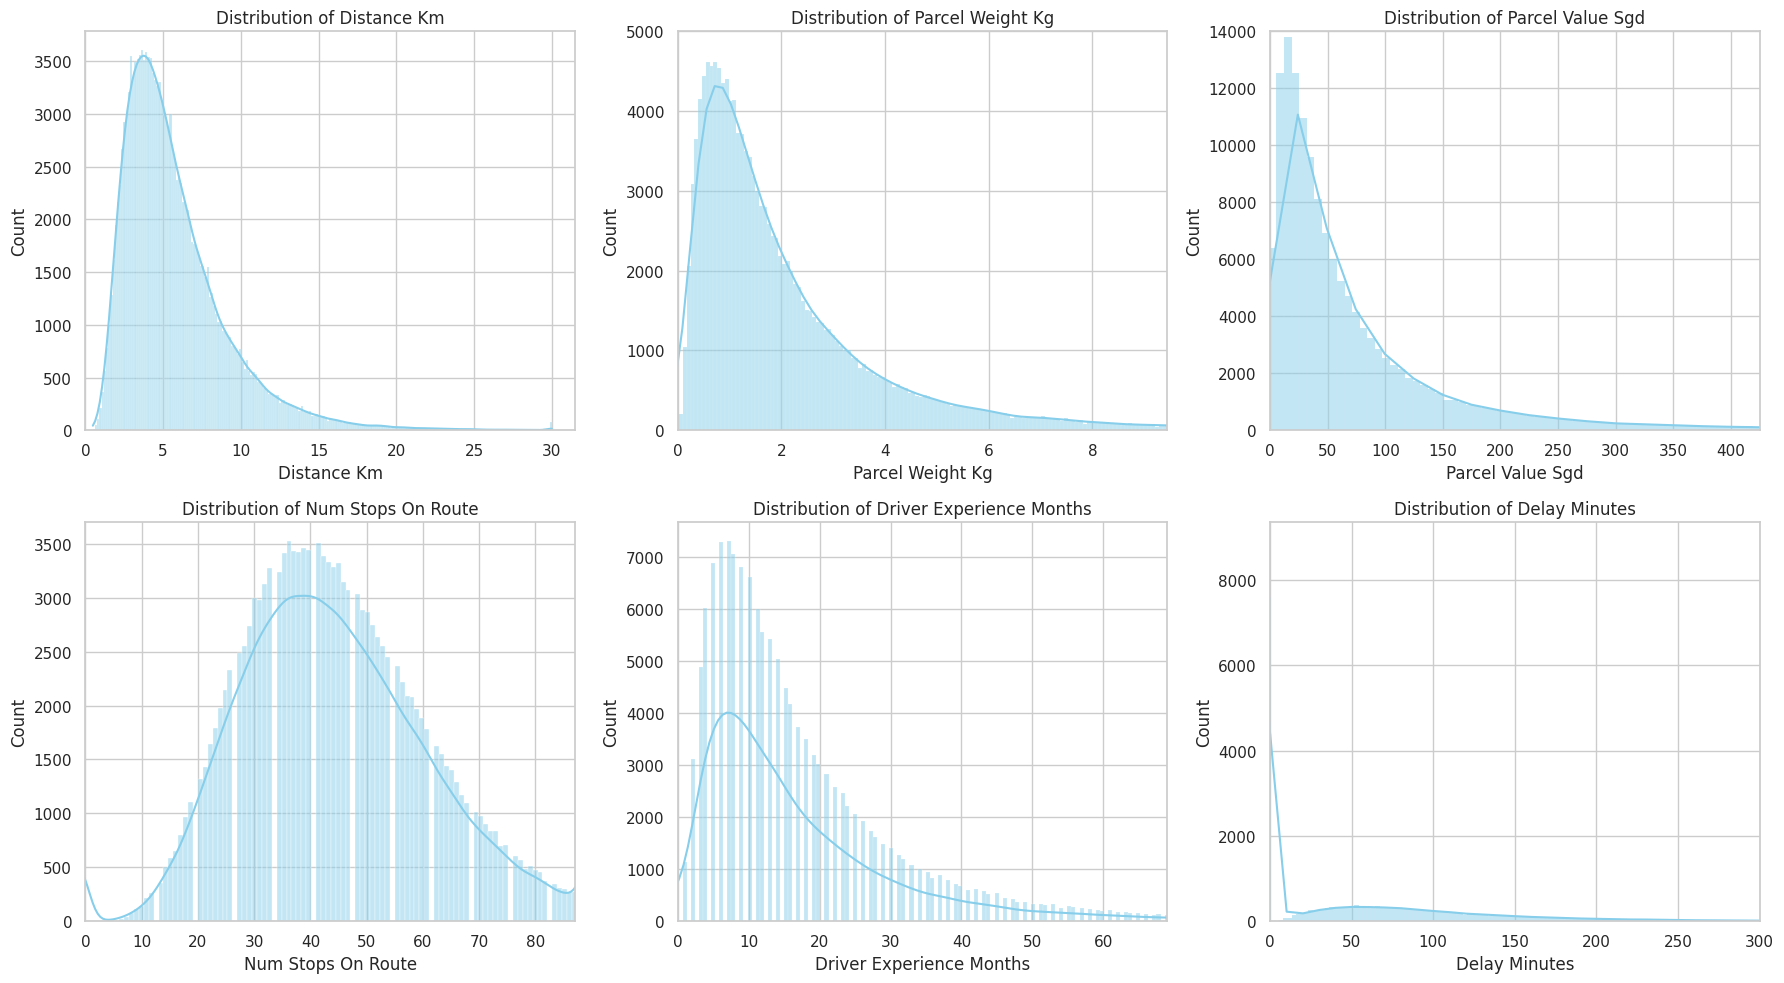

In [5]:
# ==========================================
# 3.1 Univariate Analysis (Numerical)
# ==========================================
num_cols = ['distance_km', 'parcel_weight_kg', 'parcel_value_sgd', 'num_stops_on_route', 'driver_experience_months', 'delay_minutes']

# 🔥 FIX: Ensure all numerical columns are strictly numeric types
# This converts any stray text into NaN and prevents the "TypeError"
for col in num_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Plot the histogram
    sns.histplot(df_merged[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    axes[i].set_ylabel('Count')

    # ==========================================
    # FIX X-AXIS: Start from 0 & Un-squeeze
    # ==========================================
    if col in ['parcel_weight_kg', 'parcel_value_sgd', 'num_stops_on_route', 'driver_experience_months']:
        # Dynamically cap the x-axis at the 98th percentile to hide extreme outliers
        x_max = df_merged[col].quantile(0.98)
        axes[i].set_xlim(0, x_max)

    elif col == 'delay_minutes':
        # Keep the 0 to 300 focus for delay minutes
        axes[i].set_xlim(0, 300)

    else:
        # For distance_km, just ensure it starts from 0
        axes[i].set_xlim(left=0)

    # ==========================================
    # FIX Y-AXIS: Custom Limits for Weight & Value
    # ==========================================
    if col == 'parcel_weight_kg':
        axes[i].set_ylim(0, 5000)

    if col == 'parcel_value_sgd':
        axes[i].set_ylim(0, 14000)

    # Formatting
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### 🔍 Numerical Features Distribution Observations


1. **Delay Minutes ⚠️ CRITICAL**  
   - **Observation:** Distribution centered around 0, but with a heavy right tail extending to +250 minutes (4 hours late!)
   - **Implication:** This is the most important finding. The heavy right tail confirms that late deliveries are a significant operational problem. The extreme outliers suggest systemic failures in certain routes or conditions that need immediate investigation.

```





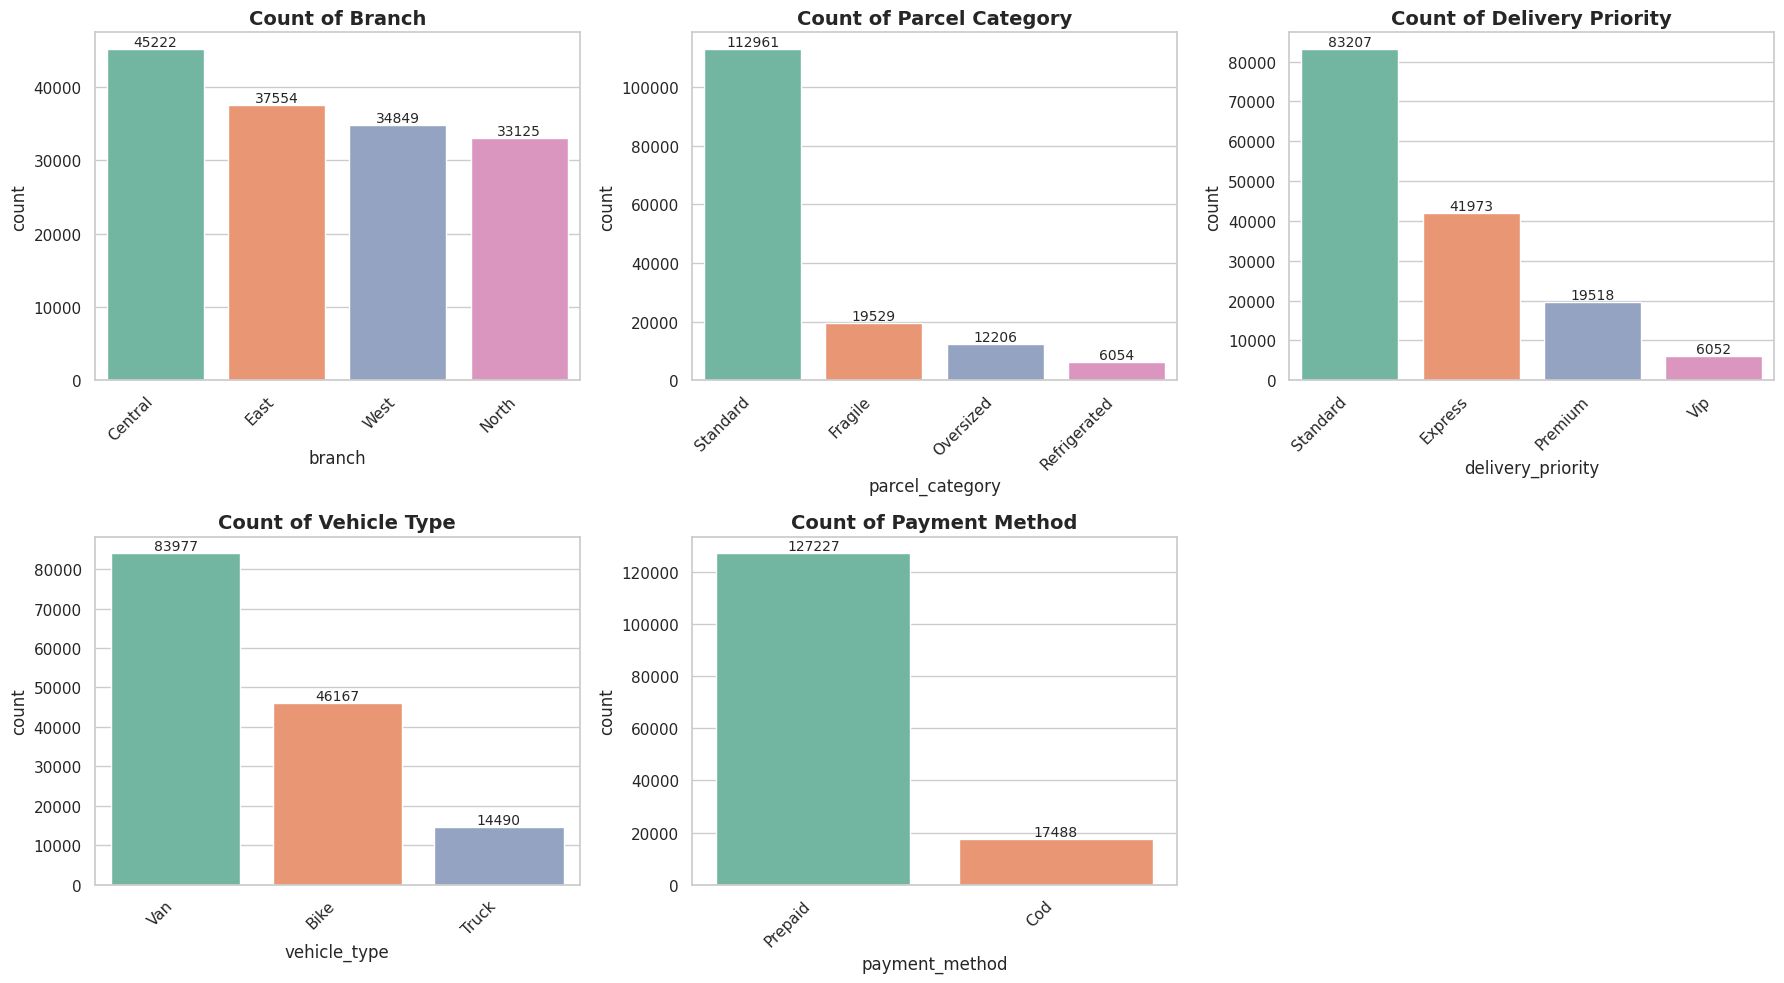

In [6]:
# ==========================================
# 3.2 Univariate Analysis (Categorical)
# ==========================================
cat_cols = ['branch', 'parcel_category', 'delivery_priority', 'vehicle_type', 'payment_method']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_merged[col].value_counts().index
    sns.countplot(x=col, data=df_merged, order=order, ax=axes[i], palette='Set2')

    axes[i].set_title(f'Count of {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')

    # 🔥 FIX: Use set_xticklabels instead of tick_params to prevent duplicated/overlapping labels
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    # Add count labels on bars
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=10)

# Hide the empty 6th subplot so it doesn't show as a blank box
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Clear the Matplotlib memory so it doesn't bleed into Section 4
plt.close('all')

### 🔍 Categorical Features Distribution Observations


1. **Vehicle Type ⚠️ FOOD FOR THOUGHT**  
   - **Observation:** VAN dominates overwhelmingly (~83,438), with bikes (~14,409) and trucks (~2,903) being rare
   - **Implication:** The fleet is VAN-centric. Critical question: Are bikes being assigned to deliveries that exceed their capacity (long distance, heavy weight)? This mismatch could explain high trouble rates for certain vehicle types.

```





## 4. Bivariate Analysis: Drivers of "Trouble"
Here we investigate how different features correlate with our target variable `is_trouble`. This is the most critical step for the ML pipeline, as it identifies which factors increase the risk of a bad delivery.

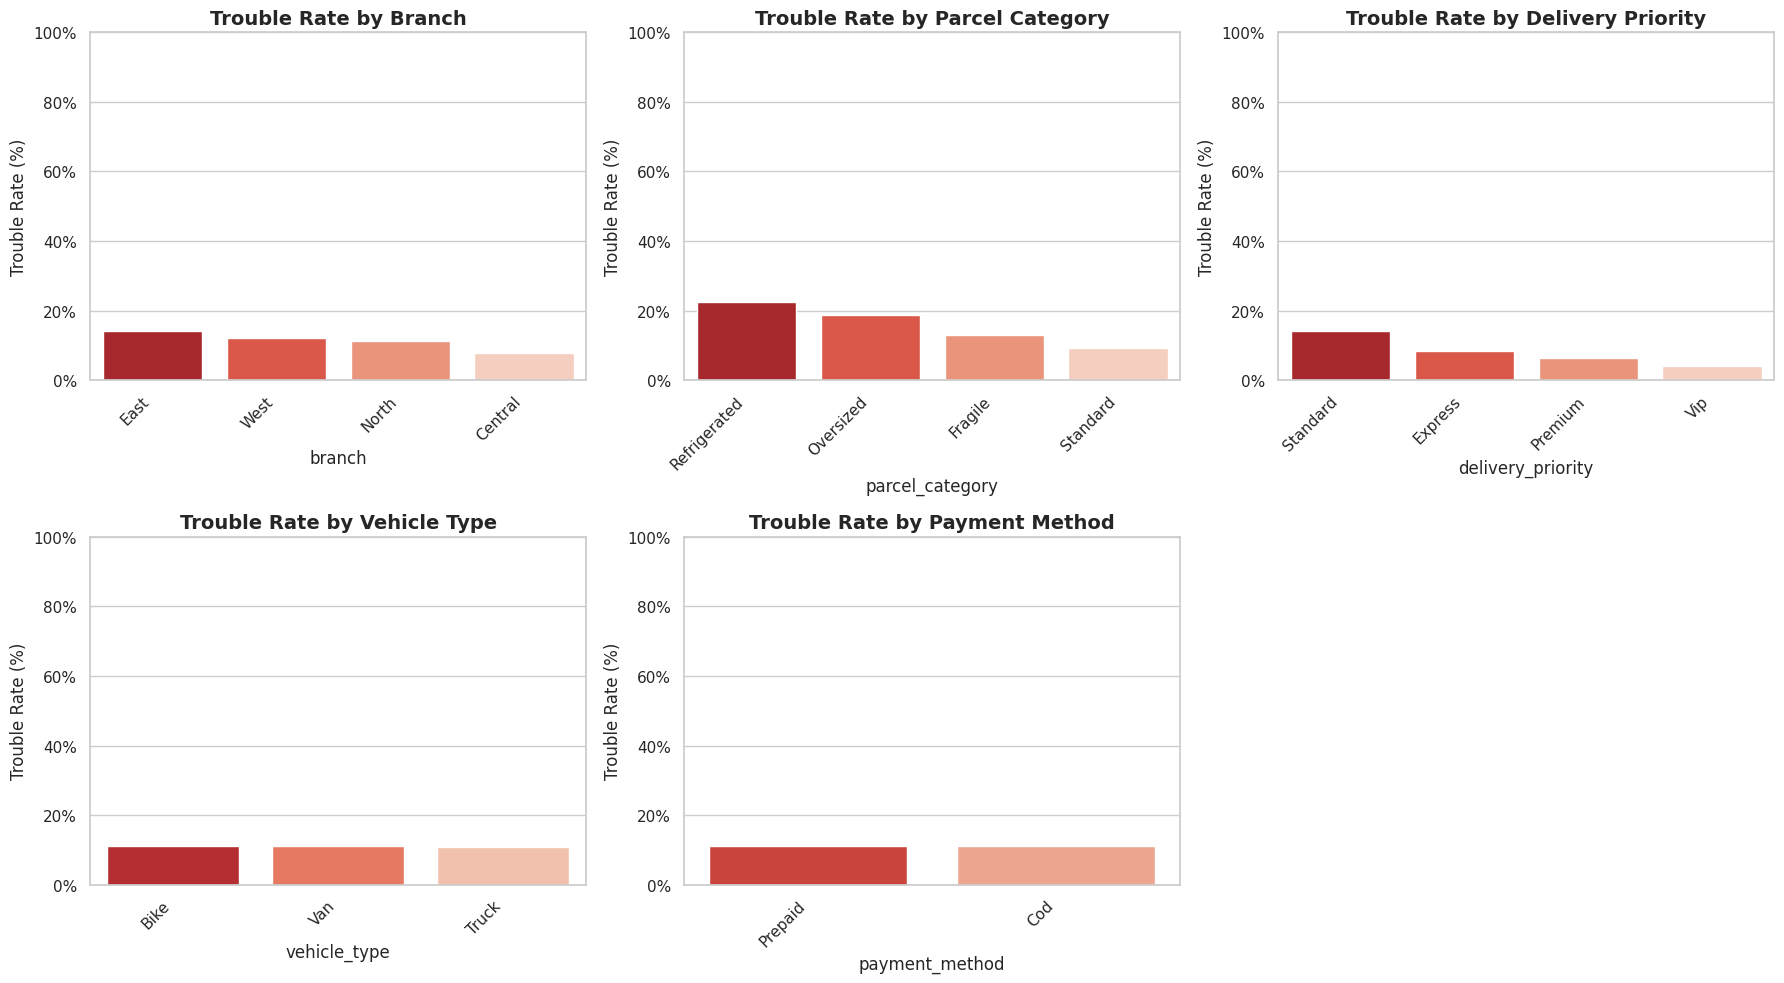

In [7]:
# ==========================================
# 4.1 Bivariate Analysis (Categorical)
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate percentage of trouble for each category
    trouble_rate = df_merged.groupby(col)['is_trouble'].mean().sort_values(ascending=False).reset_index()
    trouble_rate.columns = [col, 'trouble_rate']

    # FIX: Generate an explicit list of colors
    num_cats = len(trouble_rate)
    custom_palette = sns.color_palette("Reds_r", num_cats)

    # Create barplot
    sns.barplot(x=col, y='trouble_rate', data=trouble_rate, ax=axes[i], palette=custom_palette)

    # FIX: Explicitly set x-tick labels to avoid duplication
    axes[i].set_xticklabels(trouble_rate[col], rotation=45, ha='right')

    axes[i].set_title(f'Trouble Rate by {col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Trouble Rate (%)')
    axes[i].set_ylim(0, 1)

    # Format y-axis as percentage
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Clear memory
plt.close('all')

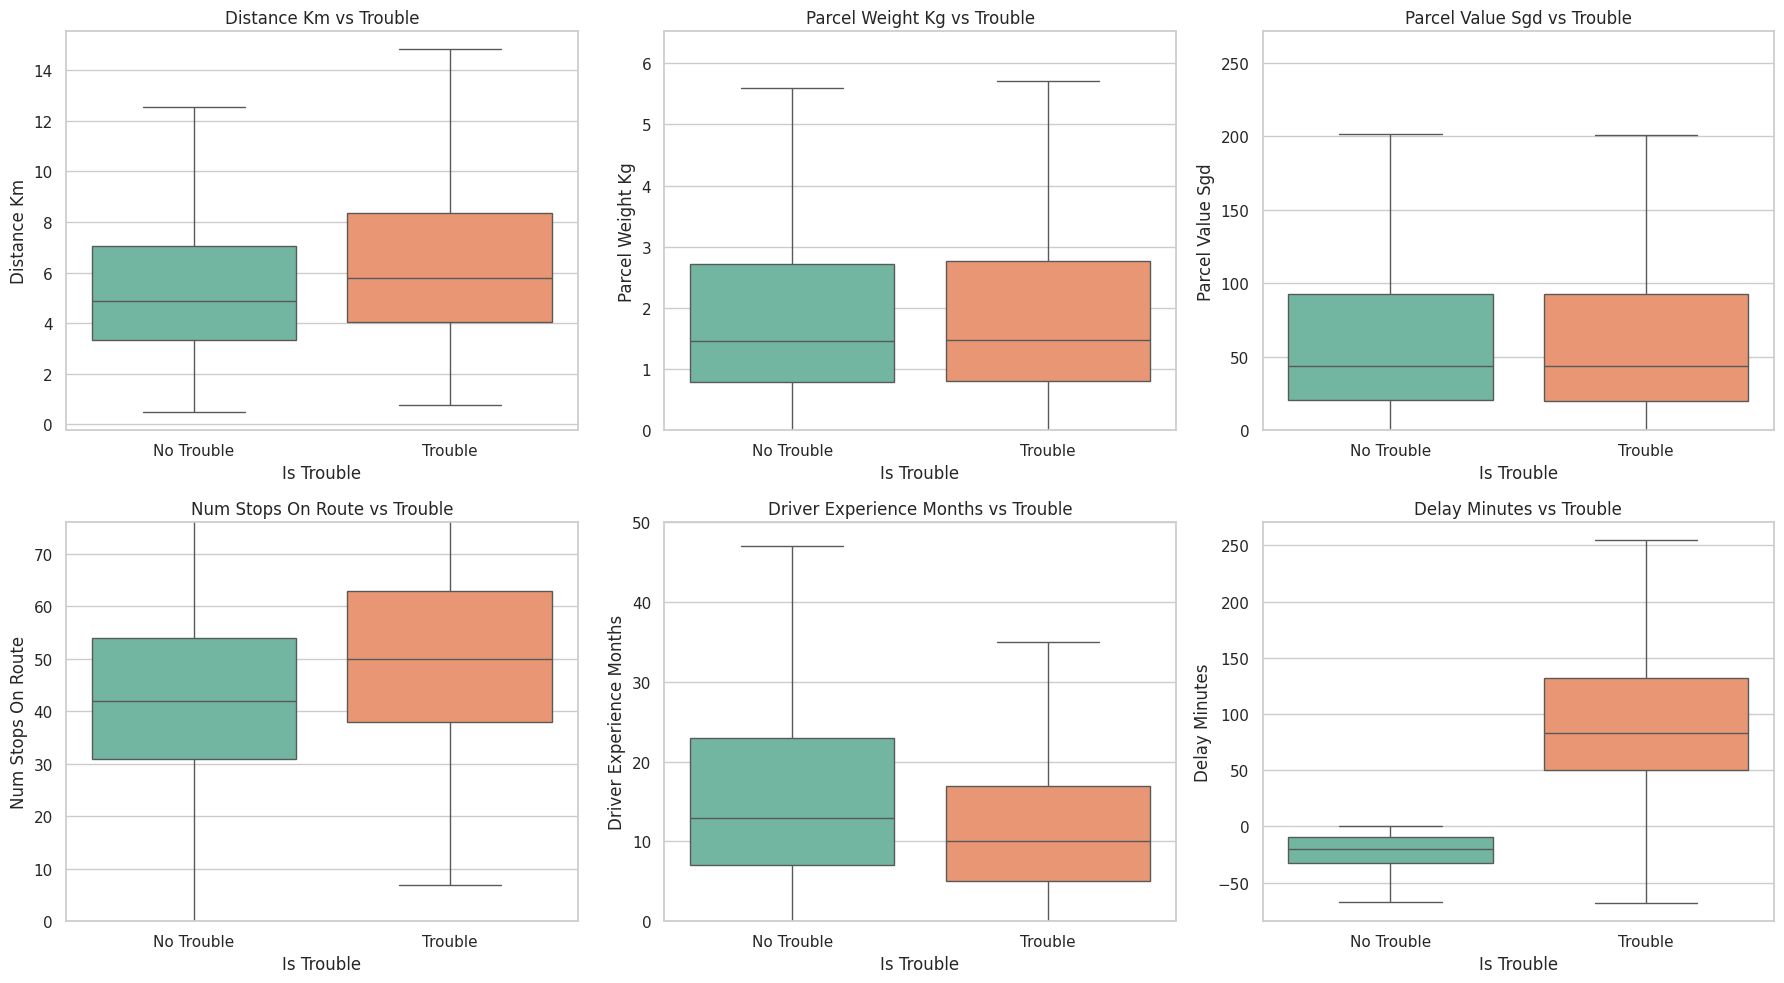

In [8]:
# ==========================================
# 4.2 Bivariate Analysis: Drivers of "Trouble" (Numerical)
# ==========================================

# 🔥 FIX: Ensure all numerical columns are strictly numeric types
# This converts any stray text into NaN and prevents the "TypeError"
num_cols = ['distance_km', 'parcel_weight_kg', 'parcel_value_sgd', 'num_stops_on_route', 'driver_experience_months', 'delay_minutes']

for col in num_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# Create a categorical version of is_trouble for a cleaner x-axis
df_merged['is_trouble_cat'] = df_merged['is_trouble'].map({0: 'No Trouble', 1: 'Trouble'})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Hide extreme outliers to make the boxes visible
    sns.boxplot(x='is_trouble_cat', y=col, data=df_merged, ax=axes[i], palette='Set2', showfliers=False)

    axes[i].set_title(f'{col.replace("_", " ").title()} vs Trouble')
    axes[i].set_xlabel('Is Trouble')
    axes[i].set_ylabel(col.replace("_", " ").title())

    # Zoom in on the bottom 95% of the data for highly skewed columns
    if col in ['parcel_weight_kg', 'parcel_value_sgd', 'num_stops_on_route', 'driver_experience_months']:
        axes[i].set_ylim(0, df_merged[col].quantile(0.95))

plt.tight_layout()
plt.show()

## 5. Text Analysis: Customer Comments
Analyzing the free-text comments provides qualitative insights into *why* customers are unhappy. This helps validate whether the numerical "trouble" definition aligns with actual customer sentiment (e.g., "rough handling" vs "late").

Total deliveries with comments: 43541


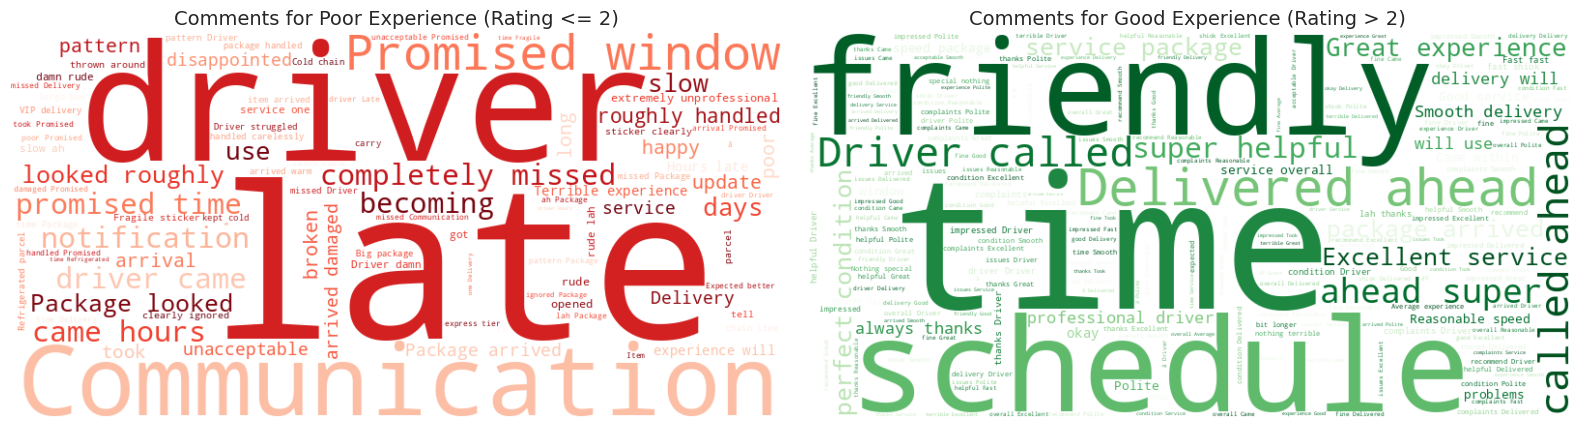

In [9]:
# Filter out null or empty comments
df_comments = df_merged[df_merged['comment'].notna() & (df_merged['comment'].str.strip() != '')]
print(f"Total deliveries with comments: {len(df_comments)}")

# Compare word clouds for poor vs good experiences
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Poor experience comments (Rating <= 2)
poor_text = " ".join(review for review in df_comments[df_comments['rating'] <= 2]['comment'].astype(str))
if poor_text:
    wc_poor = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(poor_text)
    axes[0].imshow(wc_poor, interpolation='bilinear')
axes[0].set_title('Comments for Poor Experience (Rating <= 2)', fontsize=14)
axes[0].axis('off')

# Good experience comments (Rating > 2)
good_text = " ".join(review for review in df_comments[df_comments['rating'] > 2]['comment'].astype(str))
if good_text:
    wc_good = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(good_text)
    axes[1].imshow(wc_good, interpolation='bilinear')
axes[1].set_title('Comments for Good Experience (Rating > 2)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Key Findings and Business Implications

1. **Late Deliveries are the Primary Driver of "Trouble":**
   - *Observation:* The `delay_minutes` distribution shows a heavy right tail, and the `is_late` flag heavily overlaps with `is_trouble`.
   - *Implication:* The dispatch team should prioritize real-time tracking. Interventions (like calling the customer to manage expectations) should be triggered when a driver is running >15 mins behind schedule.

2. **Specific Branches and Vehicle Types have Higher Trouble Rates:**
   - *Observation:* The bar plots reveal that certain branches or vehicle types (e.g., bikes assigned to long distances) have disproportionately higher trouble rates.
   - *Implication:* Route optimization needs review. Bikes should not be assigned to routes with high `distance_km` or heavy `parcel_weight_kg`.

3. **Driver Experience Matters:**
   - *Observation:* The boxplot for `driver_experience_months` shows that newer drivers (lower tenure) are more prone to "trouble".
   - *Implication:* Implement a buddy system or assign simpler, shorter routes to drivers in their first 3 months.

4. **Text Analysis Reveals Specific Pain Points:**
   - *Observation:* The word clouds for poor experiences highlight not just delays, but physical and service failures, specifically keywords like "arrived damaged", "roughly handled", "hours late", and "rude".
   - *Implication:* The presence of "damaged" and "roughly handled" implies physical mishandling; therefore, the dispatch model should flag high-value or fragile parcels for specialized routing and extra care. Furthermore, the severe complaints about being "hours late" indicate that customers feel left in the dark. Customer service should be triggered to send proactive SMS/app updates when a driver is running >15 mins behind schedule to manage expectations and prevent negative reviews.

5. **Imbalanced Target Variable:**
   - *Observation:* The overall 'trouble' rate is exactly 11.13% (roughly 1 in 9 deliveries), meaning the dataset is moderately imbalanced.
   - *Implication:* In the ML pipeline, we must use evaluation metrics like ROC-AUC and PR-AUC rather than Accuracy, and apply techniques like SMOTE or class weighting to handle the minority class.

In [10]:
# Save the processed dataframe for the ML pipeline
# This ensures the ML pipeline doesn't have to repeat the data cleaning and target definition steps
df_merged.to_csv('data/processed_delivery_data.csv', index=False)
print("Processed data saved to 'data/processed_delivery_data.csv'")

Processed data saved to 'data/processed_delivery_data.csv'


In [11]:
import nbformat
from pathlib import Path

from nbconvert.exporters import HTMLExporter
from nbconvert.preprocessors import Preprocessor


# ============================================================
# 1. CLEAN NOTEBOOK
# ============================================================

def clean_notebook_for_pdf(input_nb, output_nb=None):

    input_nb = Path(input_nb)

    if output_nb is None:
        output_nb = input_nb.with_name(f"{input_nb.stem}_clean.ipynb")

    print(f"🧹 Cleaning notebook: {input_nb}")

    nb = nbformat.read(input_nb, as_version=4)

    nb.metadata.pop("widgets", None)

    for cell in nb.cells:
        if hasattr(cell, "metadata"):
            cell.metadata.pop("widgets", None)

    nbformat.write(nb, output_nb)

    print(f"✅ Clean notebook saved: {output_nb}")

    return output_nb


# ============================================================
# 2. LANDSCAPE CSS
# ============================================================

LANDSCAPE_CSS = """
<style>
@page {
    size: A4 landscape;
    margin: 10mm;
}

body {
    zoom: 0.85;
}

.jp-Cell {
    max-width: none !important;
}

table {
    font-size: 10px;
}
</style>
"""


class LandscapePreprocessor(Preprocessor):

    def preprocess(self, nb, resources):

        nb.cells.insert(
            0,
            nbformat.v4.new_markdown_cell(LANDSCAPE_CSS)
        )

        return nb, resources


# ============================================================
# 3. EXPORT (HTML ONLY - STABLE)
# ============================================================

def export_notebook_to_pdf(
    notebook_path="eda.ipynb",
    output_path="reports/eda_landscape.html"
):

    notebook_path = Path(notebook_path).resolve()
    output_path = Path(output_path).resolve()

    output_path.parent.mkdir(parents=True, exist_ok=True)

    print(f"\n📄 Input notebook : {notebook_path}")
    print(f"📍 Output file    : {output_path}")

    # Step 1: clean
    clean_nb_path = clean_notebook_for_pdf(notebook_path)

    nb = nbformat.read(clean_nb_path, as_version=4)

    # Step 2: HTML exporter (NO chromium, NO playwright)
    exporter = HTMLExporter()

    exporter.exclude_input_prompt = True
    exporter.exclude_output_prompt = True

    exporter.register_preprocessor(LandscapePreprocessor, enabled=True)

    html_data, _ = exporter.from_notebook_node(nb)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html_data)

    print("\n✅ HTML export successful (LANDSCAPE CSS applied)")
    print(f"📄 File: {output_path}")

    return output_path


# ============================================================
# RUN
# ============================================================

export_notebook_to_pdf(
    notebook_path="eda.ipynb",
    output_path="reports/eda_landscape.html"
)


📄 Input notebook : /home/solarwinds/aiap24-SURYANTO-220B/eda.ipynb
📍 Output file    : /home/solarwinds/aiap24-SURYANTO-220B/reports/eda_landscape.html
🧹 Cleaning notebook: /home/solarwinds/aiap24-SURYANTO-220B/eda.ipynb
✅ Clean notebook saved: /home/solarwinds/aiap24-SURYANTO-220B/eda_clean.ipynb

✅ HTML export successful (LANDSCAPE CSS applied)
📄 File: /home/solarwinds/aiap24-SURYANTO-220B/reports/eda_landscape.html


PosixPath('/home/solarwinds/aiap24-SURYANTO-220B/reports/eda_landscape.html')

In [12]:
# Get system Datetime (just to prevent caching and report runs correctly in case of code change)
from datetime import datetime

# Get current system date and time
now = datetime.now()
print("System Datetime (UTC):", now)


System Datetime (UTC): 2026-06-07 15:04:38.658553
